# ABF + Fisher–Rao vs. plain ABF on an entropic bottleneck

## Model and exact reference

$$V(x,y)=H\,(x^2-1)^2+\tfrac12\,\omega(x)^2 y^2,\qquad
\omega(x)=\omega_{\rm out}+(\omega_{\rm in}-\omega_{\rm out})\,e^{-x^2/2s^2}.$$

A symmetric double well in $x$ (minima at $x=\pm1$, barrier height $H$) with a
**narrow $y$-channel** near $x=0$ (large $\omega$) — the entropic bottleneck.
Because the $y$-integral is Gaussian the reference is analytic:

$$F_{\rm ref}(x)=H\,(x^2-1)^2+\beta^{-1}\log\omega(x)+C,\qquad
F'_{\rm ref}(x)=4Hx(x^2-1)+\beta^{-1}\,\omega'(x)/\omega(x).$$

At low temperature (large $\beta$) barrier crossings are rare, so plain ABF
accumulates too few samples near the bottleneck/far well within the budget and
its mean-force — hence free-energy — estimate lags.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-30

# -- domain & reaction-coordinate grid -------------------------------------
XMIN, XMAX = -1.8, 1.8
YMIN, YMAX = -2.0, 2.0
n_grid = 181
x_grid = np.linspace(XMIN, XMAX, n_grid)
dx = x_grid[1] - x_grid[0]
EVAL = (x_grid >= -1.5) & (x_grid <= 1.5)      # interior window for the L2 errors
idx0 = int(np.argmin(np.abs(x_grid)))          # x nearest 0 (free-energy gauge)

# -- physical regime --------------------------------------------------------
beta      = 8.0     # inverse temperature  (cold  ->  ABF is starved)
H         = 2.5     # double-well barrier height
omega_out = 1.0     # transverse stiffness in the wells
omega_in  = 25.0    # transverse stiffness at the bottleneck (x = 0)
s         = 0.25    # bottleneck width in x

# -- particle / time budget -------------------------------------------------
N          = 256
dt         = 1e-3
n_steps    = 40000
save_every = 400
n_seeds    = 5

# -- ABF (binned-smoothed mean force) bandwidths ----------------------------
h         = 0.07    # mean-force smoothing bandwidth on x
min_count = 1.0     # low-count regularisation

# -- Fisher–Rao configuration (final, tuned) --------------------------------
gamma              = 15.0   # birth-death rate
eta                = 0.10   # marginal-density (p_hat) bandwidth
fr_every           = 10     # apply FR every 10 steps
fr_burnin          = 0      # FR active from the start
ramp_fraction      = 0.10   # soft ramp of gamma over the first 10% of steps
target_ema_rate    = 0.005  # slow EMA target free energy
score_clip         = 3.0    # clip on the Fisher–Rao score
max_event_fraction = 0.08   # cap on the per-event birth-death fraction


In [2]:
# ----------------------------- model --------------------------------------
def U(x):         return H * (x * x - 1.0) ** 2
def dU_dx(x):     return 4.0 * H * x * (x * x - 1.0)
def omega(x):     return omega_out + (omega_in - omega_out) * np.exp(-x * x / (2 * s * s))
def domega_dx(x): return -(omega_in - omega_out) * (x / s ** 2) * np.exp(-x * x / (2 * s * s))
def V(x, y):      return U(x) + 0.5 * omega(x) ** 2 * y * y
def dV_dx(x, y):  return dU_dx(x) + omega(x) * domega_dx(x) * y * y
def dV_dy(x, y):  return omega(x) ** 2 * y
def F_ref(x):     return U(x) + np.log(omega(x)) / beta            # up to a constant
def Fp_ref(x):    return dU_dx(x) + domega_dx(x) / (omega(x) * beta)

F_REF = F_ref(x_grid); F_REF = F_REF - F_REF[EVAL].mean()
FP_REF = Fp_ref(x_grid)


In [3]:
# ------------------- hand-rolled numerics (numpy only) --------------------
def gaussian_kernel(bw):
    r = max(1, int(round(4.0 * bw / dx)))
    k = np.exp(-0.5 * (np.arange(-r, r + 1) * dx / bw) ** 2)
    return k / (k.sum() * dx), r

def smooth(v, k, r):
    pad = min(r, len(v) - 1)
    return np.convolve(np.pad(v, (pad, pad), mode="reflect"),
                       k[r - pad:len(k) - (r - pad)], mode="valid")

def reflect(q, lo, hi):
    span = hi - lo; q = np.mod(q - lo, 2 * span)
    return np.where(q > span, 2 * span - q, q) + lo

def cumtrapz(y):
    return np.concatenate([[0.0], np.cumsum(0.5 * (y[1:] + y[:-1]) * dx)])

def binned_density(X, k, r):
    idx = np.clip(np.round((X - XMIN) / dx).astype(int), 0, n_grid - 1)
    p = smooth(np.bincount(idx, minlength=n_grid).astype(float), k, r) / len(X)
    return np.maximum(p / max(np.trapezoid(p, dx=dx), EPS), EPS)

def l2(a, b):                                   # interior-window RMS error
    return float(np.sqrt(np.mean((a[EVAL] - b[EVAL]) ** 2)))

# ------------------- Fisher–Rao target and birth-death --------------------
def fr_target(F_target, B):                     # q(x) ~ exp(-beta (F_target - B))
    e = -beta * (F_target - B); e -= e.max(); q = np.exp(e)
    return np.maximum(q / max(np.trapezoid(q, dx=dx), EPS), EPS)

def fr_resample(X, Y, anc, S, g, dt_fr, rng):
    n = len(X); u = rng.uniform(size=n)
    pos, neg = S > 0, S < 0
    die = pos & (u < np.clip(1 - np.exp(-g * S * dt_fr), 0, 1))
    clone = neg & (u < np.clip(1 - np.exp(g * S * dt_fr), 0, 1))
    cap = int(np.floor(max_event_fraction * n)); nev = int(die.sum() + clone.sum())
    if nev > cap:                               # gentle safety cap
        di, ci = np.where(die)[0], np.where(clone)[0]
        kd = min(int(round(cap * len(di) / max(nev, 1))), len(di)); kc = min(cap - kd, len(ci))
        die = np.zeros(n, bool); clone = np.zeros(n, bool)
        if kd > 0: die[rng.choice(di, kd, replace=False)] = True
        if kc > 0: clone[rng.choice(ci, kc, replace=False)] = True
    surv = np.where(~die)[0]; new = np.concatenate([surv, np.where(clone)[0]]).astype(int)
    if len(new) < n: new = np.concatenate([new, rng.choice(surv, n - len(new), replace=True)])
    elif len(new) > n: new = new[rng.choice(len(new), n, replace=False)]
    return X[new], Y[new], anc[new]


In [4]:
# ----------------------- the two methods ----------------------------------
def simulate(use_fr, seed):
    # one ABF (use_fr=False) or ABF+FR (use_fr=True) run, with matched seeds
    rng_i = np.random.default_rng(1000 + seed)   # initial conditions
    rng_n = np.random.default_rng(2000 + seed)   # Langevin noise
    rng_f = np.random.default_rng(3000 + seed)   # Fisher–Rao
    k_h, r_h = gaussian_kernel(h); k_eta, r_eta = gaussian_kernel(eta)

    X = reflect(rng_i.normal(-1.0, 0.05, N), XMIN, XMAX)         # all start in the left well
    Y = rng_i.normal(0.0, np.sqrt(1.0 / (beta * omega(X) ** 2))) # exact conditional Y|X
    anc = np.arange(N)
    C = np.zeros(n_grid); Sf = np.zeros(n_grid); F_target = np.zeros(n_grid)
    noise = np.sqrt(2.0 * dt / beta)
    ramp = int(ramp_fraction * n_steps)
    diag = dict(t=[], l2_f=[], l2_fp=[], F_hat=None, Fp_hat=None)

    for step in range(n_steps):
        fx, fy = dV_dx(X, Y), dV_dy(X, Y)
        idx = np.clip(np.round((X - XMIN) / dx).astype(int), 0, n_grid - 1)
        C += np.bincount(idx, minlength=n_grid)
        Sf += np.bincount(idx, weights=fx, minlength=n_grid)
        Fp = smooth(Sf, k_h, r_h) / (smooth(C, k_h, r_h) + min_count + EPS)   # mean force
        B = cumtrapz(Fp); B = B - B[idx0]                                     # bias = free energy
        F_target = (1 - target_ema_rate) * F_target + target_ema_rate * B

        Xp = reflect(X + (-fx + np.interp(X, x_grid, Fp)) * dt + noise * rng_n.standard_normal(N), XMIN, XMAX)
        Yp = Y + (-fy) * dt + noise * rng_n.standard_normal(N)

        if use_fr and step >= fr_burnin and (step - fr_burnin) % fr_every == 0:
            g = gamma * (1 - np.exp(-max((step - fr_burnin) / ramp, 0.0))) if ramp > 0 else gamma
            if g > 0:
                p = binned_density(Xp, k_eta, r_eta)
                q = fr_target(F_target, B)
                kl = np.trapezoid(p * (np.log(p) - np.log(q)), dx=dx)
                S = np.log(np.maximum(np.interp(Xp, x_grid, p), EPS)) \
                    - np.log(np.maximum(np.interp(Xp, x_grid, q), EPS)) - kl
                Xp, Yp, anc = fr_resample(Xp, Yp, anc, np.clip(S, -score_clip, score_clip),
                                          g, dt * fr_every, rng_f)
        X, Y = Xp, Yp

        if step % save_every == 0 or step == n_steps - 1:
            Bc = B - B[EVAL].mean()
            diag["t"].append(step * dt); diag["l2_f"].append(l2(Bc, F_REF)); diag["l2_fp"].append(l2(Fp, FP_REF))
            diag["F_hat"], diag["Fp_hat"] = Bc, Fp
    diag["t"] = np.array(diag["t"]); diag["l2_f"] = np.array(diag["l2_f"]); diag["l2_fp"] = np.array(diag["l2_fp"])
    return diag

def simulate_abf_only(seed): return simulate(False, seed)
def simulate_abf_fr(seed):   return simulate(True, seed)


In [5]:
# --------------------------- run the comparison ---------------------------
import time
t0 = time.time()
abf = [simulate_abf_only(s) for s in range(n_seeds)]
fr  = [simulate_abf_fr(s)   for s in range(n_seeds)]
print(f"ran {2*n_seeds} simulations in {time.time()-t0:.0f}s\n")

def med(runs, key): return np.median([r[key] for r in runs], axis=0)
fa = np.median([r["l2_f"][-1] for r in abf]);  ff = np.median([r["l2_f"][-1] for r in fr])
pa = np.median([r["l2_fp"][-1] for r in abf]); pf = np.median([r["l2_fp"][-1] for r in fr])
P  = np.mean([fr[i]["l2_f"][-1] < abf[i]["l2_f"][-1] for i in range(n_seeds)])
print(f"median final L2(F) :  ABF = {fa:.3f}   ABF+FR = {ff:.3f}   (ABF+FR / ABF = {ff/fa:.2f}, -{100*(1-ff/fa):.0f}%)")
print(f"median final L2(F'):  ABF = {pa:.3f}   ABF+FR = {pf:.3f}   (-{100*(1-pf/pa):.0f}%)")
print(f"P(ABF+FR final L2(F) < ABF) over {n_seeds} matched seeds = {P:.2f}")


ran 10 simulations in 29s

median final L2(F) :  ABF = 0.188   ABF+FR = 0.095   (ABF+FR / ABF = 0.51, -49%)
median final L2(F'):  ABF = 1.730   ABF+FR = 1.090   (-37%)
P(ABF+FR final L2(F) < ABF) over 5 matched seeds = 1.00


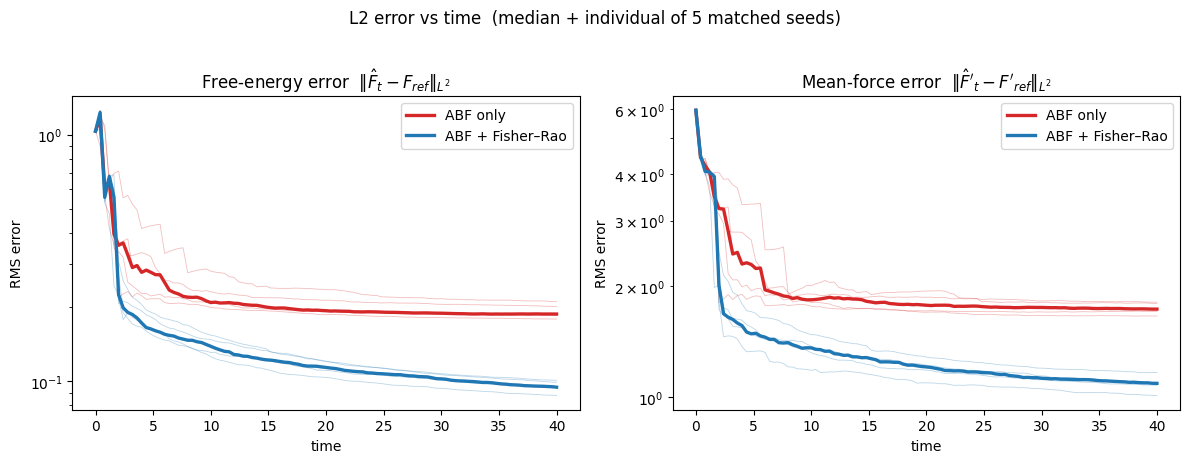

In [6]:
# --------------- result: L2 error vs time (median over seeds) -------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
T = abf[0]["t"]
for ax, key, ttl in [(axes[0], "l2_f", "Free-energy error  $\\|\\hat F_t-F_{ref}\\|_{L^2}$"),
                     (axes[1], "l2_fp", "Mean-force error  $\\|\\hat F'_t-F'_{ref}\\|_{L^2}$")]:
    for r in abf: ax.plot(r["t"], r[key], color="C3", lw=0.6, alpha=0.30)
    for r in fr:  ax.plot(r["t"], r[key], color="C0", lw=0.6, alpha=0.30)
    ax.plot(T, med(abf, key), color="C3", lw=2.4, label="ABF only")
    ax.plot(T, med(fr,  key), color="C0", lw=2.4, label="ABF + Fisher–Rao")
    ax.set(xlabel="time", ylabel="RMS error", yscale="log", title=ttl); ax.legend()
fig.suptitle(f"L2 error vs time  (median + individual of {n_seeds} matched seeds)", y=1.02)
plt.tight_layout(); plt.show()


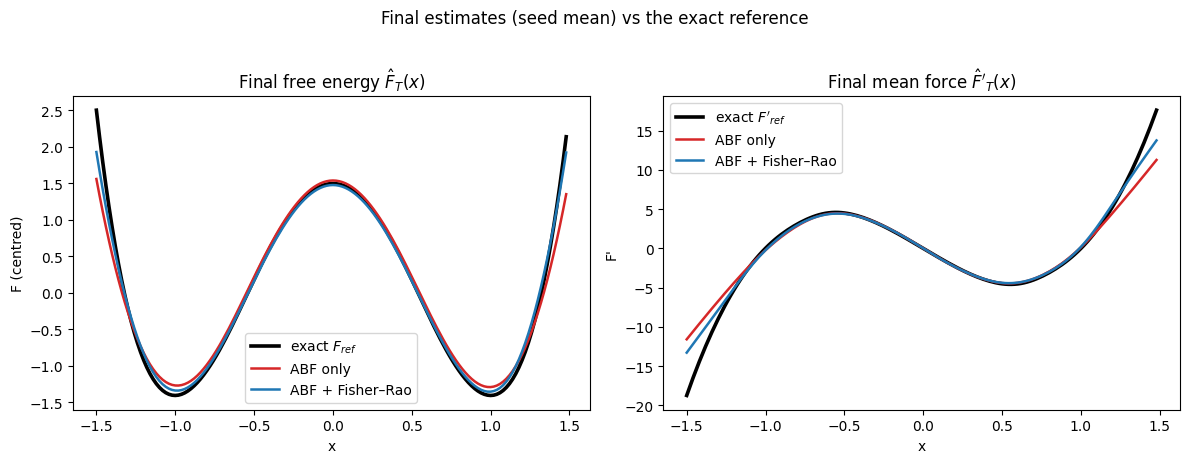

In [7]:
# --------------- result: final estimated profiles vs exact ----------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
xw = x_grid[EVAL]
FA = np.mean([r["F_hat"] for r in abf], 0); FF = np.mean([r["F_hat"] for r in fr], 0)
PA = np.mean([r["Fp_hat"] for r in abf], 0); PF = np.mean([r["Fp_hat"] for r in fr], 0)
axes[0].plot(xw, F_REF[EVAL], "k", lw=2.6, label="exact $F_{ref}$")
axes[0].plot(xw, FA[EVAL], "C3", lw=1.8, label="ABF only")
axes[0].plot(xw, FF[EVAL], "C0", lw=1.8, label="ABF + Fisher–Rao")
axes[0].set(xlabel="x", ylabel="F (centred)", title="Final free energy $\\hat F_T(x)$"); axes[0].legend()
axes[1].plot(xw, FP_REF[EVAL], "k", lw=2.6, label="exact $F'_{ref}$")
axes[1].plot(xw, PA[EVAL], "C3", lw=1.8, label="ABF only")
axes[1].plot(xw, PF[EVAL], "C0", lw=1.8, label="ABF + Fisher–Rao")
axes[1].set(xlabel="x", ylabel="F'", title="Final mean force $\\hat F'_T(x)$"); axes[1].legend()
fig.suptitle("Final estimates (seed mean) vs the exact reference", y=1.02)
plt.tight_layout(); plt.show()
